In [7]:
# Bloc 1 — Datensatz erstellen und laden
import pandas as pd
import numpy as np

np.random.seed(42)  # macht die Zufallszahlen reproduzierbar
n = 1000            # Anzahl Bestellungen

regionen  = ["Nord", "Süd", "Ost", "West", "Mitte"]
kategorien = ["Elektronik", "Kleidung", "Haushalt", "Bücher", "Sport"]

# Basis-Lieferzeit je Region (in Tagen) – "Ost" ist bewusst langsamer
liefer_basis = {"Nord": 3, "Süd": 3, "Ost": 6, "West": 4, "Mitte": 3}

# Zufällige Bestelldaten im Jahr 2024
start = pd.Timestamp("2024-01-01")
bestelldatum = start + pd.to_timedelta(np.random.randint(0, 365, n), unit="D")

region    = np.random.choice(regionen, n, p=[0.25, 0.25, 0.15, 0.20, 0.15])
kategorie = np.random.choice(kategorien, n)

# Lieferzeit = Basiswert der Region + Zufallsanteil
lieferzeit   = np.array([liefer_basis[r] for r in region]) + np.random.randint(0, 4, n)
lieferdatum  = bestelldatum + pd.to_timedelta(lieferzeit, unit="D")

menge = np.random.randint(1, 6, n)
preis_basis = {"Elektronik": 250, "Kleidung": 40, "Haushalt": 80, "Bücher": 15, "Sport": 60}
einzelpreis = np.array([preis_basis[k] for k in kategorie]) * np.random.uniform(0.8, 1.2, n)

# Tabelle (DataFrame) zusammenbauen
df = pd.DataFrame({
    "bestell_id":   range(1, n + 1),
    "bestelldatum": bestelldatum,
    "lieferdatum":  lieferdatum,
    "region":       region,
    "kategorie":    kategorie,
    "menge":        menge,
    "einzelpreis":  einzelpreis.round(2),
})
df["umsatz"] = (df["menge"] * df["einzelpreis"]).round(2)

df.to_csv("bestelldaten.csv", index=False)  # als CSV speichern (fürs GitHub-Repo)
print("Datensatz erstellt:", df.shape)
df.head()

Datensatz erstellt: (1000, 8)


,bestell_id,bestelldatum,lieferdatum,region,kategorie,menge,einzelpreis,umsatz
0,1,2024-04-12,2024-04-21,Ost,Bücher,3,12.30,36.90
1,2,2024-12-14,2024-12-20,Nord,Sport,5,49.27,246.35
2,3,2024-09-27,2024-10-03,Süd,Bücher,1,16.15,16.15
3,4,2024-04-16,2024-04-20,Nord,Kleidung,5,39.33,196.65
4,5,2024-03-12,2024-03-17,Nord,Sport,3,53.44,160.32


In [8]:
# Bloc 2 — Daten erkunden und vorbereiten

# 1) Überblick: Datentypen und fehlende Werte
print("=== Infos zum Datensatz ===")
df.info()

# 2) Gibt es fehlende Werte?
print("\n=== Fehlende Werte pro Spalte ===")
print(df.isnull().sum())

# 3) Neue Spalte: Lieferdauer in Tagen (Lieferdatum - Bestelldatum)
df["lieferdauer_tage"] = (df["lieferdatum"] - df["bestelldatum"]).dt.days

# 4) Statistische Kurzübersicht der Zahlen-Spalten
print("\n=== Statistische Übersicht ===")
df[["menge", "einzelpreis", "umsatz", "lieferdauer_tage"]].describe().round(2)

=== Infos zum Datensatz ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   bestell_id    1000 non-null   int64         
 1   bestelldatum  1000 non-null   datetime64[ns]
 2   lieferdatum   1000 non-null   datetime64[ns]
 3   region        1000 non-null   object        
 4   kategorie     1000 non-null   object        
 5   menge         1000 non-null   int64         
 6   einzelpreis   1000 non-null   float64       
 7   umsatz        1000 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(2), object(2)
memory usage: 62.6+ KB

=== Fehlende Werte pro Spalte ===
bestell_id      0
bestelldatum    0
lieferdatum     0
region          0
kategorie       0
menge           0
einzelpreis     0
umsatz          0
dtype: int64

=== Statistische Übersicht ===


,menge,einzelpreis,umsatz,lieferdauer_tage
count,1000.00,1000.00,1000.00,1000.00
mean,3.00,87.53,260.79,5.13
std,1.41,84.55,296.66,1.54
min,1.00,12.03,12.03,3.00
25%,2.00,34.00,65.53,4.00
50%,3.00,58.84,157.50,5.00
75%,4.00,85.70,295.63,6.00
max,5.00,299.20,1472.85,9.00


In [9]:
# Bloc 3 — Analyse: Umsatz und Lieferzeiten

# A) Umsatz pro Region (absteigend sortiert)
umsatz_region = df.groupby("region")["umsatz"].sum().sort_values(ascending=False)
print("=== Gesamtumsatz pro Region (€) ===")
print(umsatz_region.round(2))

# B) Umsatz pro Produktkategorie
umsatz_kategorie = df.groupby("kategorie")["umsatz"].sum().sort_values(ascending=False)
print("\n=== Gesamtumsatz pro Kategorie (€) ===")
print(umsatz_kategorie.round(2))

# C) Durchschnittliche Lieferdauer pro Region  ← der wichtigste Teil
liefer_region = df.groupby("region")["lieferdauer_tage"].mean().sort_values(ascending=False)
print("\n=== Durchschnittliche Lieferdauer pro Region (Tage) ===")
print(liefer_region.round(2))

# D) Anzahl Bestellungen pro Region
anzahl_region = df.groupby("region")["bestell_id"].count().sort_values(ascending=False)
print("\n=== Anzahl Bestellungen pro Region ===")
print(anzahl_region)

=== Gesamtumsatz pro Region (€) ===
region
Nord     68598.53
West     58415.24
Süd      53157.23
Mitte    44879.33
Ost      35744.38
Name: umsatz, dtype: float64

=== Gesamtumsatz pro Kategorie (€) ===
kategorie
Elektronik    145107.70
Haushalt       46210.91
Sport          38010.07
Kleidung       21658.08
Bücher          9807.95
Name: umsatz, dtype: float64

=== Durchschnittliche Lieferdauer pro Region (Tage) ===
region
Ost      7.48
West     5.45
Mitte    4.57
Nord     4.48
Süd      4.48
Name: lieferdauer_tage, dtype: float64

=== Anzahl Bestellungen pro Region ===
region
Nord     263
Süd      227
West     204
Mitte    160
Ost      146
Name: bestell_id, dtype: int64


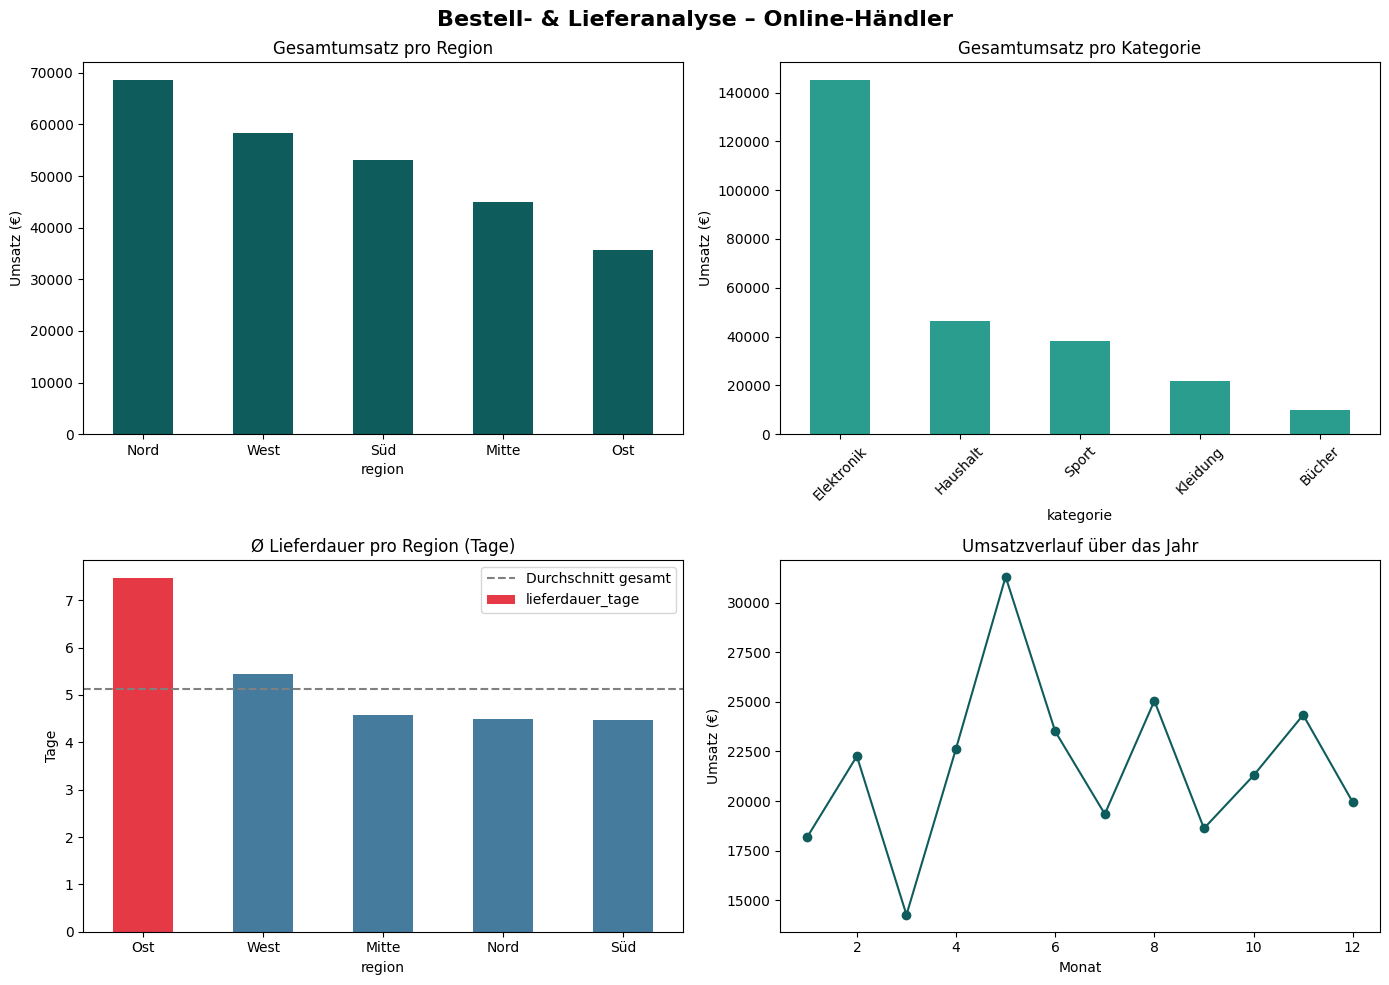

In [10]:
# Bloc 4 — Visualisierung (Mini-Dashboard)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bestell- & Lieferanalyse – Online-Händler", fontsize=16, fontweight="bold")

# 1) Umsatz pro Region
umsatz_region.plot(kind="bar", ax=axes[0, 0], color="#0F5C5C")
axes[0, 0].set_title("Gesamtumsatz pro Region")
axes[0, 0].set_ylabel("Umsatz (€)")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2) Umsatz pro Kategorie
umsatz_kategorie.plot(kind="bar", ax=axes[0, 1], color="#2A9D8F")
axes[0, 1].set_title("Gesamtumsatz pro Kategorie")
axes[0, 1].set_ylabel("Umsatz (€)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3) Durchschnittliche Lieferdauer pro Region  (Problem sichtbar machen)
farben = ["#E63946" if x == liefer_region.max() else "#457B9D" for x in liefer_region]
liefer_region.plot(kind="bar", ax=axes[1, 0], color=farben)
axes[1, 0].set_title("Ø Lieferdauer pro Region (Tage)")
axes[1, 0].set_ylabel("Tage")
axes[1, 0].axhline(df["lieferdauer_tage"].mean(), color="gray", linestyle="--", label="Durchschnitt gesamt")
axes[1, 0].legend()
axes[1, 0].tick_params(axis="x", rotation=0)

# 4) Monatlicher Umsatzverlauf
df["monat"] = df["bestelldatum"].dt.month
umsatz_monat = df.groupby("monat")["umsatz"].sum()
umsatz_monat.plot(kind="line", ax=axes[1, 1], marker="o", color="#0F5C5C")
axes[1, 1].set_title("Umsatzverlauf über das Jahr")
axes[1, 1].set_xlabel("Monat")
axes[1, 1].set_ylabel("Umsatz (€)")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")  # fürs GitHub-Repo
plt.show()

In [11]:
# Bloc 5 — Erkenntnisse & Handlungsempfehlung
print("""
=================================================================
  BESTELL- & LIEFERANALYSE – WICHTIGSTE ERKENNTNISSE
=================================================================

1. UMSATZ
   - Umsatzstärkste Region: NORD (~68.600 €)
   - Umsatzstärkste Kategorie: ELEKTRONIK (~145.000 €,
     mehr als alle anderen Kategorien zusammen)

2. LIEFERZEITEN – zentrales Problem
   - Region OST hat mit 7,5 Tagen die mit Abstand
     laengste Lieferdauer (Durchschnitt gesamt: 5,1 Tage)
   - OST ist gleichzeitig die umsatzschwaechste Region
     UND hat die wenigsten Bestellungen (146)

3. HYPOTHESE
   - Die langsame Lieferung in OST koennte ein Grund fuer
     die geringe Nachfrage sein (langsam -> weniger Bestellungen)

4. HANDLUNGSEMPFEHLUNG
   - Logistikprozesse in der Region OST pruefen und optimieren,
     um Lieferzeiten zu senken und moegliches Umsatzpotenzial
     zu erschliessen.
=================================================================
""")


  BESTELL- & LIEFERANALYSE – WICHTIGSTE ERKENNTNISSE

1. UMSATZ
   - Umsatzstärkste Region: NORD (~68.600 €)
   - Umsatzstärkste Kategorie: ELEKTRONIK (~145.000 €,
     mehr als alle anderen Kategorien zusammen)

2. LIEFERZEITEN – zentrales Problem
   - Region OST hat mit 7,5 Tagen die mit Abstand
     laengste Lieferdauer (Durchschnitt gesamt: 5,1 Tage)
   - OST ist gleichzeitig die umsatzschwaechste Region
     UND hat die wenigsten Bestellungen (146)

3. HYPOTHESE
   - Die langsame Lieferung in OST koennte ein Grund fuer
     die geringe Nachfrage sein (langsam -> weniger Bestellungen)

4. HANDLUNGSEMPFEHLUNG
   - Logistikprozesse in der Region OST pruefen und optimieren,
     um Lieferzeiten zu senken und moegliches Umsatzpotenzial
     zu erschliessen.

